# LOLA exercices

## Install and load the required libraries

The following installation process depends on which environment you are using to execute the code. Run just one of the following cells to install the necessary libraries to run the code.

In [1]:
# Run this cell if you are in a Windows PC of the computer room
# Create a virtual environment and activate it

# !python -m venv .venv
# !.venv\Scripts\activate.bat

In [2]:
# Lab PCs
# !pip install --user numpy==1.26.4 matplotlib==3.8.4 rasterio==1.4.3 pvl==1.3.2

# Any version
%pip install numpy matplotlib rasterio pvl

Note: you may need to restart the kernel to use updated packages.


In [3]:
import matplotlib.pyplot as plt
import numpy as np
from urllib.request import urlretrieve
import rasterio # Read IMG files files
import pvl # Read LBL files


## Download data

In [4]:
urlretrieve("https://imbrium.mit.edu/DATA/LOLA_GDR/CYLINDRICAL/IMG/LDEM_16.LBL", "LDEM_16.LBL")
urlretrieve("https://imbrium.mit.edu/DATA/LOLA_GDR/CYLINDRICAL/IMG/LDEM_16.IMG", "LDEM_16.IMG")


('LDEM_16.IMG', <http.client.HTTPMessage at 0x78fbc177a3f0>)

## Example code to generate a height map

In [5]:
file_name = "LDEM_16.LBL"

src = rasterio.open(file_name)

In [6]:
print(src.meta)

{'driver': 'PDS', 'dtype': 'int16', 'nodata': -32768.0, 'width': 5760, 'height': 2880, 'count': 1, 'crs': CRS.from_wkt('PROJCS["SIMPLE_CYLINDRICAL MOON",GEOGCS["GCS_MOON",DATUM["D_MOON",SPHEROID["MOON",1737400,0]],PRIMEM["Reference_Meridian",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]]],PROJECTION["Equirectangular"],PARAMETER["standard_parallel_1",0],PARAMETER["central_meridian",180],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH]]'), 'transform': Affine(1895.21, 0.0, -5458204.8,
       0.0, -1895.21, 2729102.4)}


In [7]:
dem = src.read(1)
dem.shape

(2880, 5760)

In [8]:
# -- Load .lbl file to obtain parameters
lbl_file = pvl.load(file_name)
scale = lbl_file["UNCOMPRESSED_FILE"]["IMAGE"]["SCALING_FACTOR"]
offset = lbl_file["UNCOMPRESSED_FILE"]["IMAGE"]["OFFSET"]

scale, offset

(0.5, 1737400.0)

In [9]:
# -- Apply scale and offset
# Elevation in meters
dem_scale = (dem * scale)

# Distance from the center of mass
# dem_scale = (dem * scale) + offset

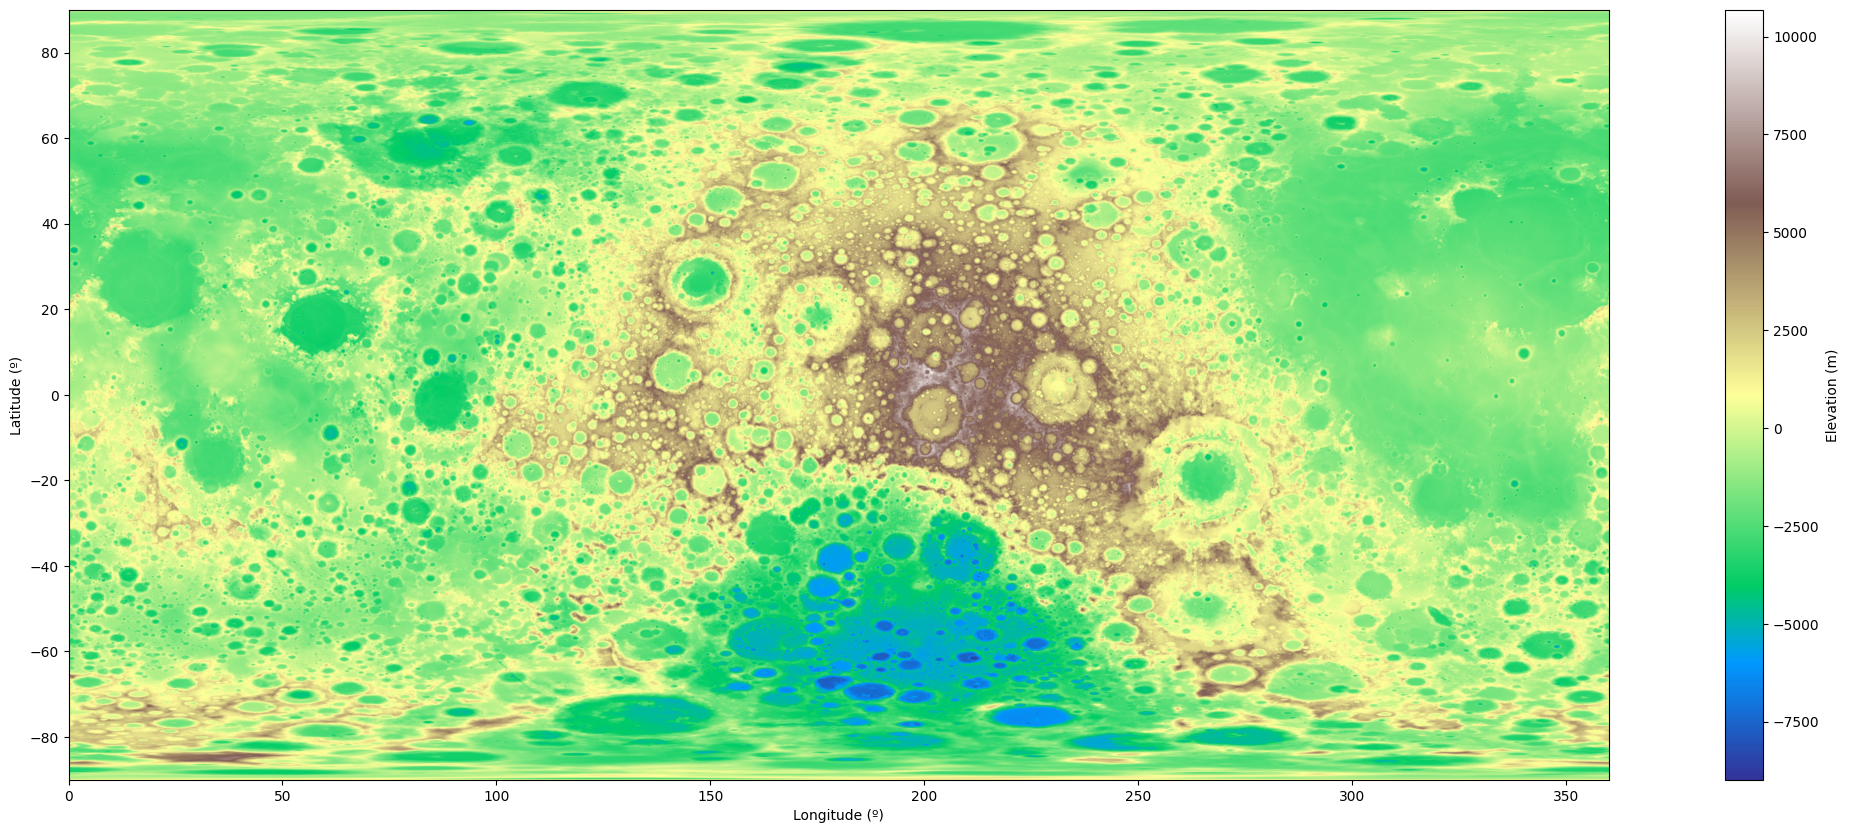

In [10]:
plt.figure(figsize=(30, 10))
plt.imshow(dem_scale, extent=[0, 360, -90, 90], cmap="terrain")
plt.xlabel("Longitude (º)")
plt.ylabel("Latitude (º)")
plt.colorbar(label="Elevation (m)")
plt.show()

# Exercice 1:


Generate a height map of the Moon as the one below but centered at the near side (0º longitude).

In [29]:
print("dem_scale is:", dem_scale.shape)
print("dem_scale.shape(0) [height]:", dem_scale.shape[0])
print("dem_scale.shape(1) [width]:", dem_scale.shape[1])

dem_scale_upgrade = np.hstack((dem_scale[:, dem_scale.shape[1]//2:], dem_scale[:, :dem_scale.shape[1]//2]))
print("dem_scale_upgrade is:", dem_scale_upgrade.shape)

dem_scale is: (2880, 5760)
dem_scale.shape(0) [height]: 2880
dem_scale.shape(1) [width]: 5760
dem_scale_upgrade is: (2880, 5760)


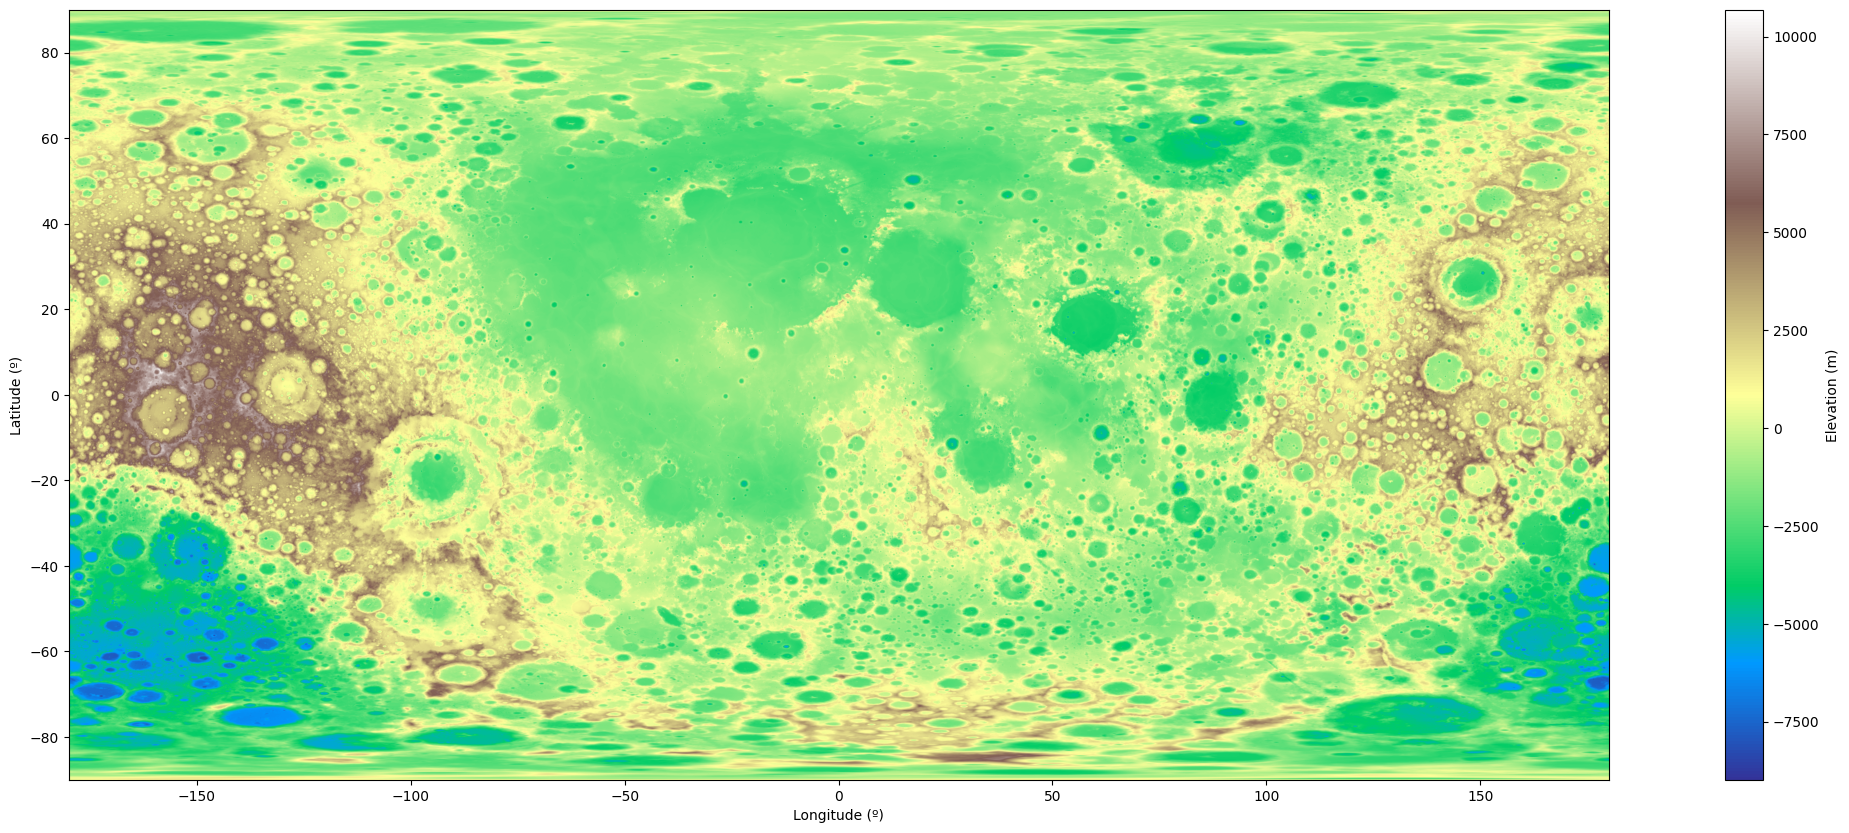

In [ ]:
# change the graph: from 180~360 and 0~180
plt.figure(figsize=(30, 10))
plt.imshow(dem_scale_upgrade, extent=[-180, 180, -90, 90], cmap="terrain")
plt.xlabel("Longitude (º)")
plt.ylabel("Latitude (º)")
plt.colorbar(label="Elevation (m)")
plt.show()


# Exercice 2:


Give the coordinates of the highest and lowest points of the Moon’s surface on the near and far side

In [35]:
# Write here the solution
max_pos = np.where(dem_scale_upgrade == np.max(dem_scale_upgrade))
min_pos = np.where(dem_scale_upgrade == np.min(dem_scale_upgrade))
print("The maximum elevation is at pixel coordinates:", max_pos)
print("The minimum elevation is at pixel coordinates:", min_pos)

print(max_pos[1][0], max_pos[0][0])
print(min_pos[1][0], min_pos[0][0])


The maximum elevation is at pixel coordinates: (array([1353]), array([341]))
The minimum elevation is at pixel coordinates: (array([2565]), array([120]))
341 1353
120 2565


In [37]:
# transfer from pixel coordinates to longitude and latitude
lon_max = (max_pos[1][0] / dem_scale_upgrade.shape[1]) * 360 - 180
lat_max = 90 - (max_pos[0][0] / dem_scale_upgrade.shape[0]) * 180
lon_min = (min_pos[1][0] / dem_scale_upgrade.shape[1]) * 360 - 180
lat_min = 90 - (min_pos[0][0] / dem_scale_upgrade.shape[0]) * 180

print("The maximum elevation is at longitude:", lon_max, "and latitude:", lat_max, "with elevation:", np.max(dem_scale_upgrade), "m")
print("The minimum elevation is at longitude:", lon_min, "and latitude:", lat_min, "with elevation:", np.min(dem_scale_upgrade), "m")
    

The maximum elevation is at longitude: -158.6875 and latitude: 5.4375 with elevation: 10685.5 m
The minimum elevation is at longitude: -172.5 and latitude: -70.3125 with elevation: -8981.5 m


# Exercice 3:


Create a histogram of heights for the near and the far side of the Moon.

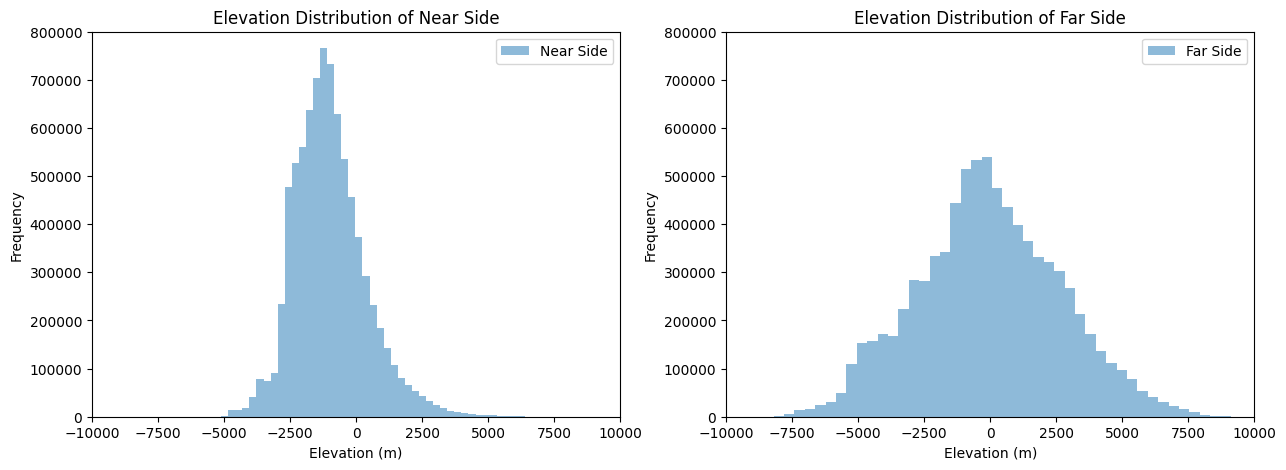

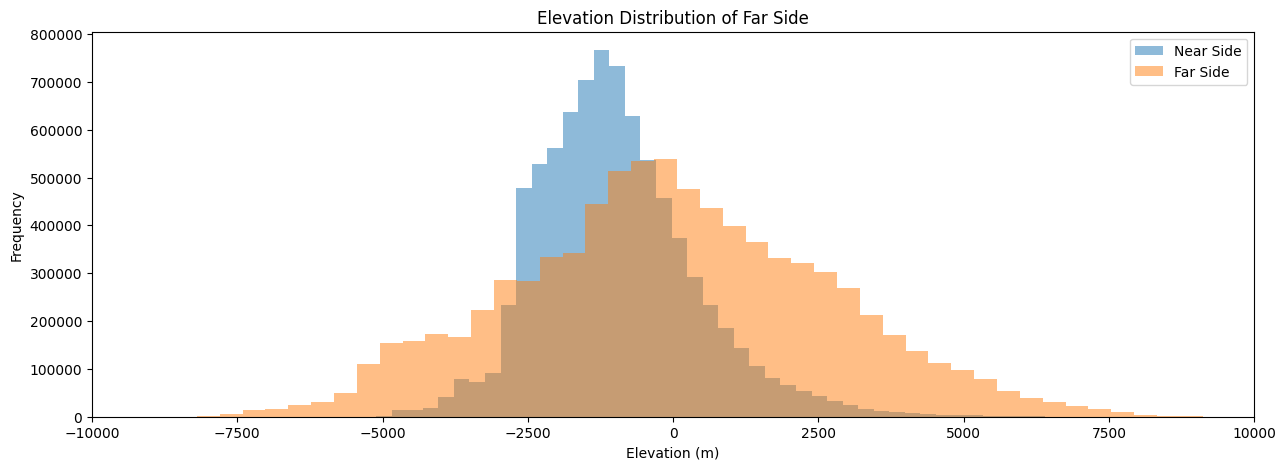

In [48]:
# Write here the solution
# from definition, near side is -90 to 90, far side is 90 to 270 
# ref: https://lroc.im-ldi.com/images/298
# create the histogram of the elevation data for the near side and far side
far_side_right = dem_scale_upgrade[:, :dem_scale_upgrade.shape[1]//4]
far_side_left = dem_scale_upgrade[:, 3*dem_scale_upgrade.shape[1]//4:]
far_side = np.hstack((far_side_right, far_side_left))
near_side = dem_scale_upgrade[:, dem_scale_upgrade.shape[1]//4:3*dem_scale_upgrade.shape[1]//4]

# plot the histogram
plt.figure(figsize=(15, 5)) 
plt.subplot(1, 2, 1)
plt.hist(near_side.flatten(), bins=50, alpha=0.5, label="Near Side")
plt.xlim(-10000, 10000) # set x-axis limits to focus on the main elevation range
plt.ylim(0, 800000) # set y-axis limits to focus on the main frequency range
plt.xlabel("Elevation (m)")
plt.ylabel("Frequency")
plt.title("Elevation Distribution of Near Side")
plt.legend()
plt.subplot(1, 2, 2)
plt.hist(far_side.flatten(), bins=50, alpha=0.5, label="Far Side")
plt.xlim(-10000, 10000) # set x-axis limits to focus on the main elevation range
plt.ylim(0, 800000) # set y-axis limits to focus on the main frequency range
plt.xlabel("Elevation (m)")
plt.ylabel("Frequency")
plt.title("Elevation Distribution of Far Side")
plt.legend()
plt.show()  

# plot together
plt.figure(figsize=(15, 5))
plt.hist(near_side.flatten(), bins=50, alpha=0.5, label="Near Side")
plt.hist(far_side.flatten(), bins=50, alpha=0.5, label="Far Side")
plt.xlabel("Elevation (m)")
plt.ylabel("Frequency")
plt.xlim(-10000, 10000) # set x-axis limits to focus on the main elevation range
plt.title("Elevation Distribution of Far Side")
plt.legend()
plt.show()   

--------

# Exercice 4:


download the file first <br/>
the directory will be [here](https://imbrium.mit.edu/BROWSE/EXTRAS/ILLUMINATION/)

In [53]:
# download data from link 
# for permanantly shadowed polar regions 
# for 85~90 degree north
urlretrieve("https://imbrium.mit.edu/EXTRAS/ILLUMINATION/JP2/LPSR_85N_060M_201608_JP2.LBL", "LPSR_85N_060M_201608_JP2.LBL")
urlretrieve("https://imbrium.mit.edu/EXTRAS/ILLUMINATION/IMG/LPSR_85N_060M_201608.IMG", "LPSR_85N_060M_201608.IMG")
# for 85~90 degree south
urlretrieve("https://imbrium.mit.edu/EXTRAS/ILLUMINATION/JP2/LPSR_85S_060M_201608_JP2.LBL", "LPSR_85S_060M_201608_JP2.LBL")
urlretrieve("https://imbrium.mit.edu/EXTRAS/ILLUMINATION/IMG/LPSR_85S_060M_201608.IMG", "LPSR_85S_060M_201608.IMG")


('LPSR_85S_060M_201608.IMG', <http.client.HTTPMessage at 0x78fba4ccc2d0>)

Create a map of the Permanently Shadowed Regions (PSRs) for both poles, given the average illumination, as the one on the right.

In [ ]:
# Write here the solution


# Exercice 5:


Where is the biggest PSR of the Moon? Give the coordinates of its approximate center.

In [ ]:
# Write here the solution

# Exercice 6:


 Give an approximation of the proportion of the permanently shadowed projected area.

In [ ]:
# Write here the solution